# DeepSeek V2 Lite: Hugging Face vs TransformerBridge

Сравнение выполняется на одинаковой модели, одинаковой 4-bit NF4-квантизации и одинаковых токенах. Модели загружаются **последовательно**, поскольку `TransformerBridge(..., hf_model=...)` модифицирует переданную HF-модель in-place, заменяя её компоненты Bridge-обёртками.

Метрики:
- latency полного forward для batch size 1;
- throughput через `PerformanceEvaluator`;
- CUDA/CPU operator profile;
- агрегированный профиль компонентов Bridge (attention, MoE и shared experts).

In [2]:
# CUDA_VISIBLE_DEVICES нужно задавать до import torch. Если контейнер уже ограничивает GPU, оставьте None.
import os
PHYSICAL_GPU = "3"
if PHYSICAL_GPU is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = PHYSICAL_GPU
os.environ.setdefault("HF_HUB_CACHE", "/glazkov-dev/.cache")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

'expandable_segments:True'

In [ ]:
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.profiler import ProfilerActivity, profile, record_function
from torch.utils.data import TensorDataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

sys.path.insert(0, "/glazkov-dev")
from utils.PerformanceEvaluator import PerformanceEvaluator
from transformer_lens.model_bridge import TransformerBridge

print("torch:", torch.__version__)
print("visible CUDA devices:", torch.cuda.device_count())
assert torch.cuda.is_available(), "Для этого benchmark требуется CUDA"
DEVICE = torch.device("cuda:0")
print("benchmark device:", torch.cuda.get_device_name(DEVICE))

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


torch: 2.10.0+cu128
visible CUDA devices: 1
benchmark device: NVIDIA A100-PCIE-40GB


## Конфигурация

Router `mlp.gate` исключён из BitsAndBytes: DeepSeek V2 обращается к `self.gate.weight` через `F.linear`, минуя `Linear4bit.forward()` и деквантизацию. Остальные крупные проекции остаются 4-битными.

In [ ]:
MODEL_ID = "deepseek-ai/DeepSeek-V2-Lite-Chat"
DTYPE = torch.float16
SEQ_LEN = 512
BATCH_SIZE = 16
N_BATCHES = 8
THROUGHPUT_REPEATS = 3
PROFILE_STEPS = 3

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=DTYPE,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    llm_int8_skip_modules=["lm_head", "mlp.gate"],
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=False)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

prompts = [
    "Explain mixture-of-experts routing in a transformer.",
    "Write a short comparison of quantization and pruning.",
    "Why does attention use a key-value cache during generation?",
    "Describe the difference between latency and throughput.",
] * (BATCH_SIZE * N_BATCHES // 4)
encoded = tokenizer(
    prompts, padding="max_length", truncation=True, max_length=SEQ_LEN, return_tensors="pt"
)
dataset = TensorDataset(encoded["input_ids"], encoded["attention_mask"])
print(encoded["input_ids"].shape)

torch.Size([64, 512])


## Адаптеры для PerformanceEvaluator

`PerformanceEvaluator` рассчитан на `model(tensor)` и вызывает `.to(device)`. Обёртки ниже делают `.to()` no-op для уже размещённой 4-bit модели и строят `attention_mask` из padding. Сырой `throughput_eval()` возвращает ms/sample; ниже он явно переводится в samples/s.

In [5]:
class LLMForwardAdapter(nn.Module):
    def __init__(self, backend, pad_token_id: int, is_bridge: bool):
        super().__init__()
        self.backend = backend
        self.pad_token_id = pad_token_id
        self.is_bridge = is_bridge

    def to(self, *args, **kwargs):
        # Quantized models must not be moved after from_pretrained(device_map=...).
        return self

    def forward(self, input_ids):
        attention_mask = input_ids.ne(self.pad_token_id).long()
        if self.is_bridge:
            return self.backend(
                input_ids, attention_mask=attention_mask, return_type="logits",
                use_cache=False, logits_to_keep=1,
            )
        return self.backend(
            input_ids=input_ids, attention_mask=attention_mask,
            use_cache=False, logits_to_keep=1, return_dict=True,
        ).logits


def load_hf_model():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, trust_remote_code=False, device_map={"": 0}, dtype=DTYPE,
        quantization_config=quantization_config, attn_implementation="eager",
    )
    model.eval()
    router = model.model.layers[1].mlp.gate
    assert isinstance(router, nn.Linear), type(router)
    assert tuple(router.weight.shape) == (model.config.n_routed_experts, model.config.hidden_size)
    return model


def release(*objects):
    for obj in objects:
        del obj
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


def benchmark_with_evaluator(adapter, label):
    evaluator = PerformanceEvaluator(
        adapter, data=dataset, device=DEVICE, batch_size=BATCH_SIZE, n_batches=N_BATCHES
    )
    evaluator.warm_up_cuda(n_batches=3)
    latency_ms = evaluator.latency_eval()
    ms_per_sample = evaluator.throughput_eval(THROUGHPUT_REPEATS)
    result = {
        "backend": label,
        "latency_ms_mean": float(np.mean(latency_ms)),
        "latency_ms_std": float(np.std(latency_ms)),
        "ms_per_sample_mean": float(np.mean(ms_per_sample)),
        "ms_per_sample_std": float(np.std(ms_per_sample)),
        "throughput_samples_s": float(1000.0 / np.mean(ms_per_sample)),
    }
    return result, evaluator

## 1. TransformerBridge

Сначала HF загружает корректно квантизированную модель, затем Bridge оборачивает именно этот объект. Это необходимо, потому что `hf_config_overrides` не передаёт `quantization_config` в `from_pretrained()`.

In [6]:
bridge_hf_model = load_hf_model()
bridge = TransformerBridge.boot_transformers(
    MODEL_ID, hf_model=bridge_hf_model, dtype=DTYPE, tokenizer=tokenizer
)
bridge.eval()
bridge_adapter = LLMForwardAdapter(bridge, tokenizer.pad_token_id, is_bridge=True)

bridge_result, bridge_evaluator = benchmark_with_evaluator(bridge_adapter, "TransformerBridge")
pd.DataFrame([bridge_result])

Loading weights:   0%|          | 0/351 [00:00<?, ?it/s]

warming: 4it [00:02,  1.82it/s]                       
throughput eval batches:  50%|█████     | 4/8 [00:05<00:05,  1.39s/batch]


,backend,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s
0,TransformerBridge,150.919537,25.442507,28.979029,0.152675,34.507712


## Детальный профиль Bridge

Профилировочные hooks добавляют одинаковые `record_function`-метки ко всем attention/MoE/shared-expert компонентам. `key_averages()` автоматически агрегирует их по типам, без послойной таблицы. Профилирование запускается отдельно и не влияет на основной benchmark.

In [7]:
def install_component_ranges(bridge_model):
    handles = []
    active_ranges = {}

    def add_range(module, label):
        def pre_hook(mod, args):
            ctx = record_function(label)
            ctx.__enter__()
            active_ranges[id(mod)] = ctx

        def post_hook(mod, args, output):
            active_ranges.pop(id(mod)).__exit__(None, None, None)

        handles.append(module.register_forward_pre_hook(pre_hook))
        handles.append(module.register_forward_hook(post_hook))

    for block in bridge_model.blocks:
        add_range(block.attn, "bridge_component::attention")
        add_range(block.mlp, "bridge_component::moe_or_dense_mlp")
        if hasattr(block.mlp, "shared_experts"):
            add_range(block.mlp.shared_experts, "bridge_component::shared_experts")
    return handles


profile_batch = encoded["input_ids"][:BATCH_SIZE].to(DEVICE)
for _ in range(2):
    with torch.inference_mode():
        bridge_adapter(profile_batch)
torch.cuda.synchronize()

range_handles = install_component_ranges(bridge)
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True, profile_memory=True, with_stack=False,
) as bridge_profiler:
    for _ in range(PROFILE_STEPS):
        with record_function("bridge_model_inference"):
            with torch.inference_mode():
                bridge_adapter(profile_batch)
        torch.cuda.synchronize()

for handle in range_handles:
    handle.remove()

print(bridge_profiler.key_averages().table(sort_by="cpu_time_total", row_limit=25))
print(bridge_profiler.key_averages().table(sort_by="self_cuda_time_total", row_limit=25))

/glazkov-dev/.venv/lib/python3.10/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                 bridge_model_inference         3.09%      44.274ms        99.35%        1.425s     475.116ms       0.000us         0.00%        1.355s     451.811ms           0 B          -6 B           0 B     -92.62 G

In [8]:
def profiler_frame(prof):
    rows = []
    for event in prof.key_averages():
        rows.append({
            "name": event.key,
            "calls": event.count,
            "cpu_time_total_ms": event.cpu_time_total / 1000.0,
            "self_cpu_time_total_ms": event.self_cpu_time_total / 1000.0,
            "cuda_time_total_ms": getattr(event, "device_time_total", 0.0) / 1000.0,
            "self_cuda_time_total_ms": getattr(event, "self_device_time_total", 0.0) / 1000.0,
        })
    return pd.DataFrame(rows)

bridge_profile_df = profiler_frame(bridge_profiler)
component_profile = (
    bridge_profile_df[bridge_profile_df["name"].str.startswith("bridge_component::")]
    .sort_values("cuda_time_total_ms", ascending=False)
)
display(component_profile)

top_cuda_ops = bridge_profile_df.nlargest(20, "self_cuda_time_total_ms")
display(top_cuda_ops[["name", "calls", "self_cuda_time_total_ms", "cpu_time_total_ms"]])

trace_path = Path("/glazkov-dev/LoRa-Transfer-Pruning/experiments/deepseek_bridge_trace.json")
bridge_profiler.export_chrome_trace(str(trace_path))
print("Chrome trace:", trace_path)

,name,calls,cpu_time_total_ms,self_cpu_time_total_ms,cuda_time_total_ms,self_cuda_time_total_ms
118,bridge_component::moe_or_dense_mlp,81,0.000000,0.000000,931.239035,931.239035
113,bridge_component::moe_or_dense_mlp,81,1108.121487,34.432347,869.255974,0.000000
89,bridge_component::attention,81,0.000000,0.000000,321.966146,321.966146
76,bridge_component::attention,81,219.491179,64.641821,316.078177,0.000000
178,bridge_component::shared_experts,78,0.000000,0.000000,130.842205,130.842205
175,bridge_component::shared_experts,78,95.810318,25.089069,129.017204,0.000000


,name,calls,self_cuda_time_total_ms,cpu_time_total_ms
4,bridge_model_inference,3,1432.038266,0.000000
118,bridge_component::moe_or_dense_mlp,81,931.239035,0.000000
85,aten::mm,10632,682.914040,182.392422
94,ampere_fp16_s16816gemm_fp16_128x128_ldg8_f2f_s...,1476,530.668542,0.000000
89,bridge_component::attention,81,321.966146,0.000000
63,aten::mul,1299,179.457635,19.645206
178,bridge_component::shared_experts,78,130.842205,0.000000
9,aten::copy_,1947,118.734469,614.291777
36,aten::index,393,71.067696,11.017335
20,"void at::native::vectorized_gather_kernel<16, ...",159,69.278693,0.000000


Chrome trace: /glazkov-dev/LoRa-Transfer-Pruning/experiments/deepseek_bridge_trace.json


## Освобождение Bridge и повторная загрузка чистой HF-модели

In [9]:
del bridge_evaluator, bridge_adapter, bridge, bridge_hf_model, bridge_profiler
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print("allocated GiB:", torch.cuda.memory_allocated(DEVICE) / 2**30)

allocated GiB: 0.007996559143066406


## 2. Чистый Hugging Face

In [10]:
hf_model = load_hf_model()
hf_adapter = LLMForwardAdapter(hf_model, tokenizer.pad_token_id, is_bridge=False)
hf_result, hf_evaluator = benchmark_with_evaluator(hf_adapter, "Hugging Face")
pd.DataFrame([hf_result])

Loading weights:   0%|          | 0/351 [00:00<?, ?it/s]

warming: 4it [00:01,  2.25it/s]                       
throughput eval batches:  50%|█████     | 4/8 [00:05<00:05,  1.33s/batch]


,backend,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s
0,Hugging Face,170.374962,0.640506,27.664388,0.084471,36.147555


## Сводная таблица и графики

,latency_ms_mean,latency_ms_std,ms_per_sample_mean,ms_per_sample_std,throughput_samples_s,latency_overhead_pct,throughput_change_pct
backend,,,,,,,
TransformerBridge,150.920,25.443,28.979,0.153,34.508,-11.419,-4.537
Hugging Face,170.375,0.641,27.664,0.084,36.148,0.000,0.000


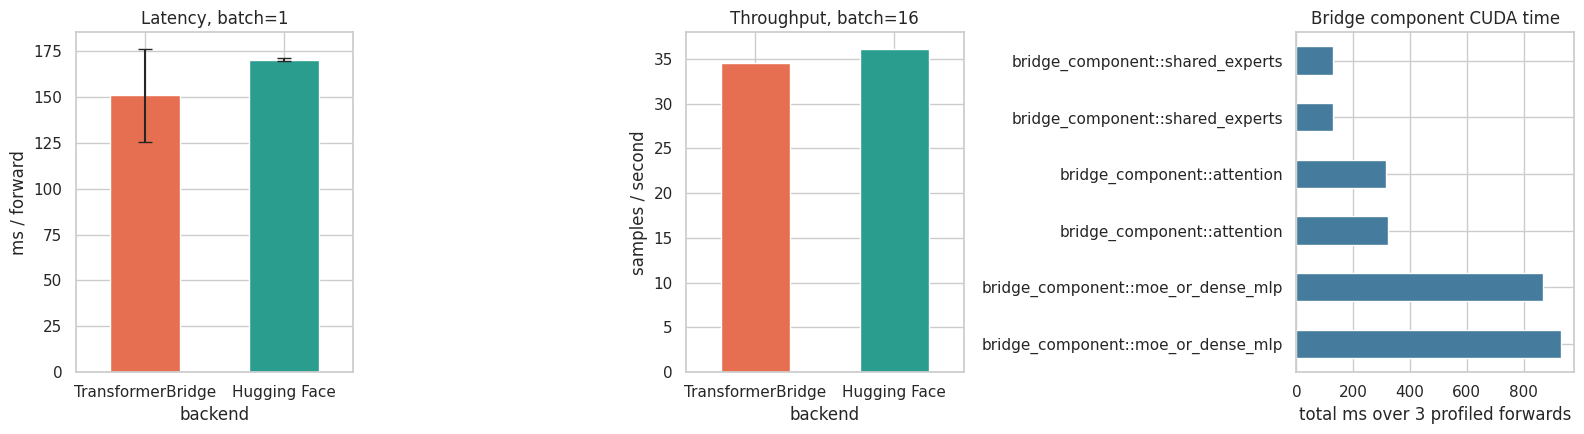

In [11]:
results = pd.DataFrame([bridge_result, hf_result]).set_index("backend")
results["latency_overhead_pct"] = (
    results["latency_ms_mean"] / results.loc["Hugging Face", "latency_ms_mean"] - 1
) * 100
results["throughput_change_pct"] = (
    results["throughput_samples_s"] / results.loc["Hugging Face", "throughput_samples_s"] - 1
) * 100
display(results.round(3))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

results["latency_ms_mean"].plot.bar(
    ax=axes[0], yerr=results["latency_ms_std"], capsize=5, color=["#e76f51", "#2a9d8f"]
)
axes[0].set_title("Latency, batch=1")
axes[0].set_ylabel("ms / forward")
axes[0].tick_params(axis="x", rotation=0)

results["throughput_samples_s"].plot.bar(
    ax=axes[1], color=["#e76f51", "#2a9d8f"]
)
axes[1].set_title(f"Throughput, batch={BATCH_SIZE}")
axes[1].set_ylabel("samples / second")
axes[1].tick_params(axis="x", rotation=0)

if not component_profile.empty:
    component_profile.set_index("name")["cuda_time_total_ms"].plot.barh(
        ax=axes[2], color="#457b9d"
    )
axes[2].set_title("Bridge component CUDA time")
axes[2].set_xlabel(f"total ms over {PROFILE_STEPS} profiled forwards")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

/tmp/ipykernel_430494/716144136.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


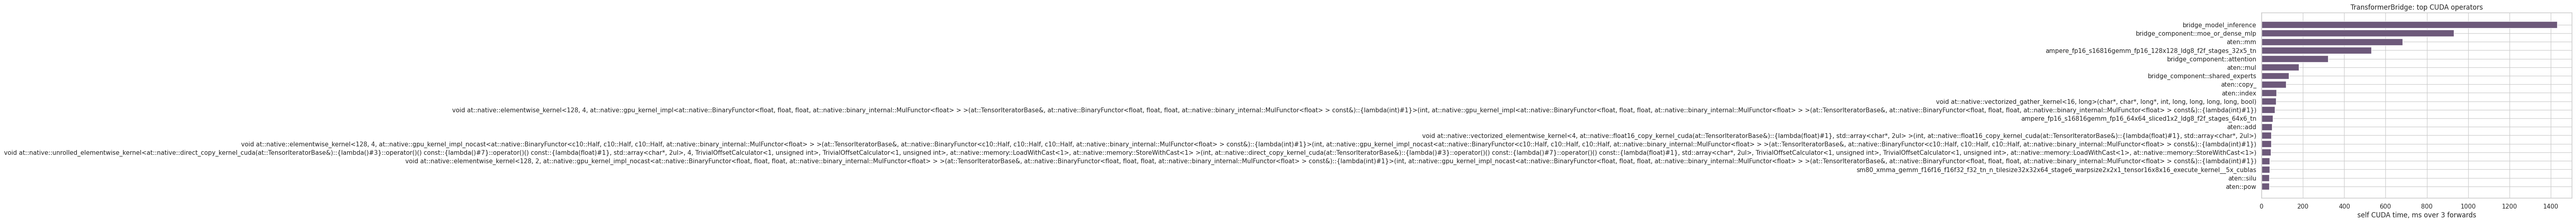

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_ops = top_cuda_ops.sort_values("self_cuda_time_total_ms")
ax.barh(plot_ops["name"], plot_ops["self_cuda_time_total_ms"], color="#6d597a")
ax.set_title("TransformerBridge: top CUDA operators")
ax.set_xlabel(f"self CUDA time, ms over {PROFILE_STEPS} forwards")
plt.tight_layout()
plt.show()